# Импорт библиотек

In [3]:
import sys
import os

sys.path.append(os.path.abspath('lib'))

from filters_features_utils import FeatureSelector, FeatureSelectorCV, get_best_xgboost_features_names
from preprocessing_pipeline import create_combined_pipeline
from test_models import run_models_regressions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from catboost import CatBoostRegressor

# Считывание данных

In [5]:
df = pd.read_csv('data/processed.csv')
df.shape

(1001, 213)

# Очистка таргета от выбросов

(997, 213)


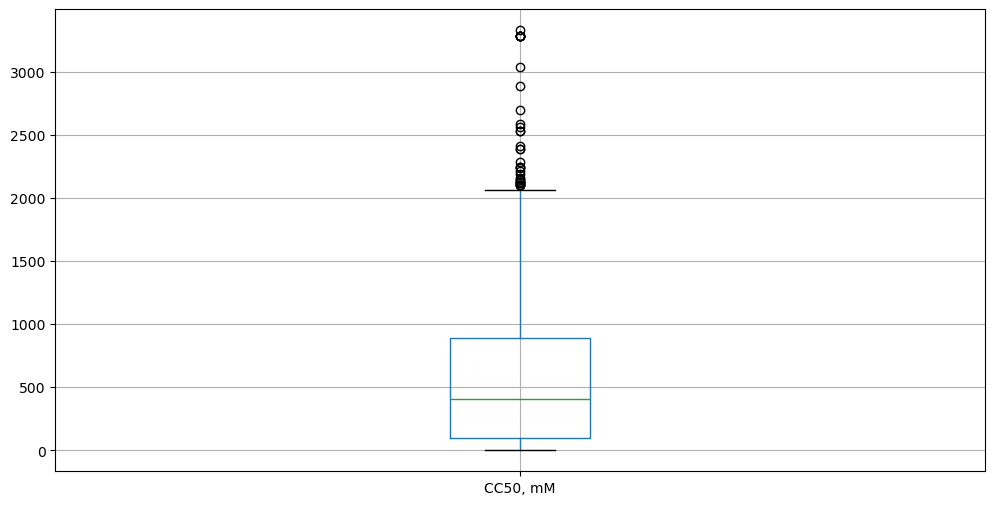

In [7]:
df = df[df['CC50, mM'] < 3500]
print(df.shape)
df.boxplot(column=['CC50, mM'], figsize=(12, 6))
plt.show()

# Подготовка данных для эксперемента

In [9]:
combined_pipeline = create_combined_pipeline()
X = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])
y1 = df['IC50, mM']
y2 = df['CC50, mM']
y3 = df['SI']
X_transformed = combined_pipeline.fit_transform(X)
df = pd.concat([X_transformed, y1, y2, y3], axis=1)
df.shape

(997, 103)

In [10]:
X = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])
y = df['CC50, mM']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train dataset size: {X_train.shape}, {y_train.shape}')
print(f'Test dataset size: {X_test.shape}, {y_test.shape}')

Train dataset size: (797, 100), (797,)
Test dataset size: (200, 100), (200,)


# Эксперемент с моделями

In [12]:
run_models_regressions(X_train, X_test, y_train, y_test)

,Model,Mean Absolute Error,R2 Score
9,Krr,272.88,0.48
4,Gradient Boosting,264.24,0.47
2,Random Forest,277.54,0.45
3,XGBoost,271.62,0.45
6,CatBoost,297.65,0.43
5,LightGBM,293.47,0.41
7,HistGradientBoosting,301.20,0.40
8,AdaBoost,395.13,0.26
0,Decision Tree,282.97,0.25
1,KNeighbors,305.79,0.15


# Фильтрация признаков

In [14]:
xgboost_features = get_best_xgboost_features_names(X_train, y_train, 100)

In [15]:
featureSelectorCV = FeatureSelectorCV()
featureSelectorCV.fit(X_train, y_train)

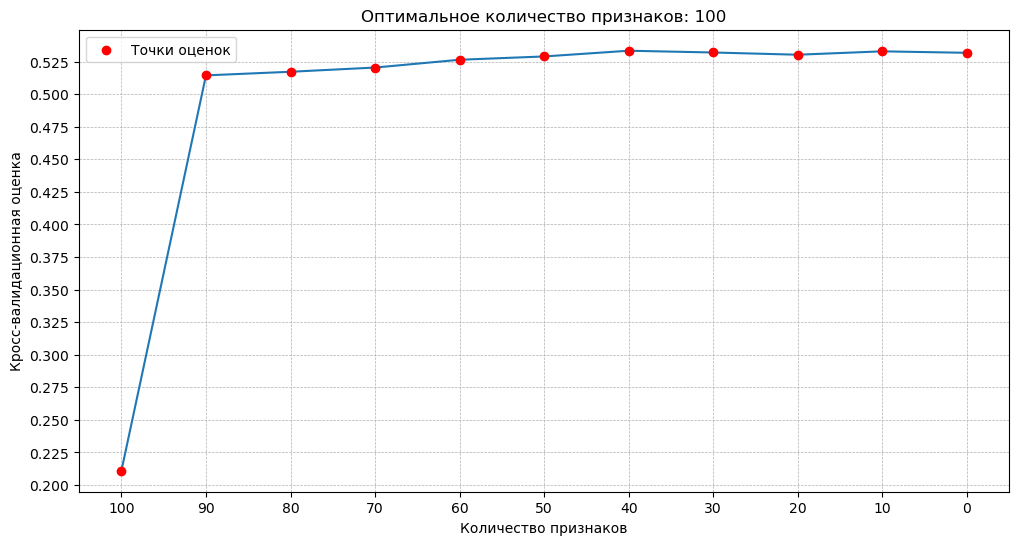

In [16]:
featureSelectorCV.plot_result()

In [17]:
model = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, random_seed=42, verbose=0)
featureSelector = FeatureSelector(model=model, start_index=5, step=5)

In [18]:
featureSelector.calculate_k_best(X_train, X_test, y_train, y_test)

K-Best Progress: 100%|██████████| 20/20 [00:05<00:00,  3.42it/s]


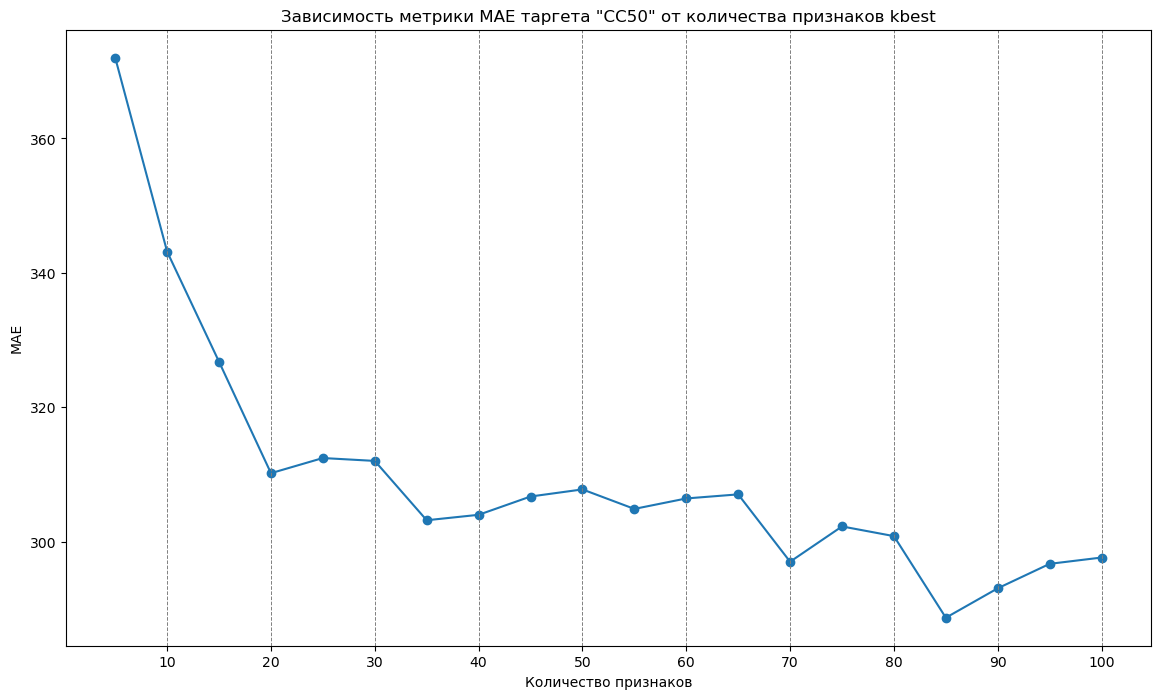

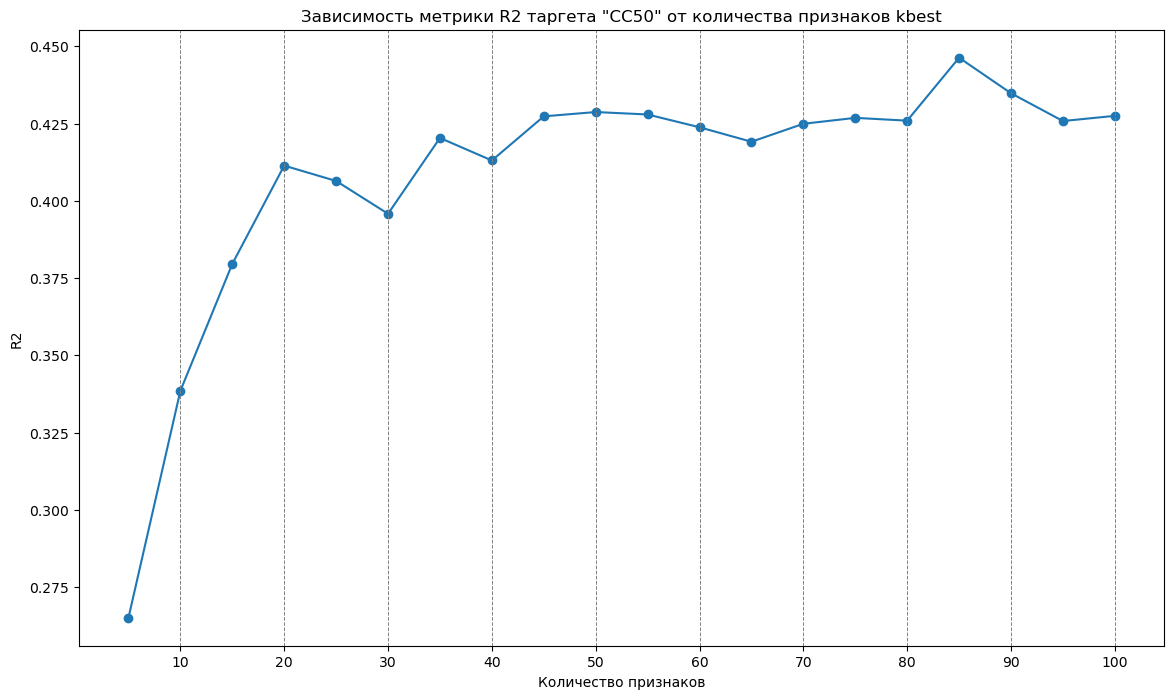

In [19]:
featureSelector.draw_selection(featureSelector.kbest_mae_scores, 'MAE', 'CC50', 'kbest')
featureSelector.draw_selection(featureSelector.kbest_r2_scores, 'R2', 'CC50', 'kbest')

In [20]:
featureSelector.calculate_rfe(X_train, X_test, y_train, y_test)

RFE Progress: 100%|██████████| 20/20 [01:32<00:00,  4.62s/it]


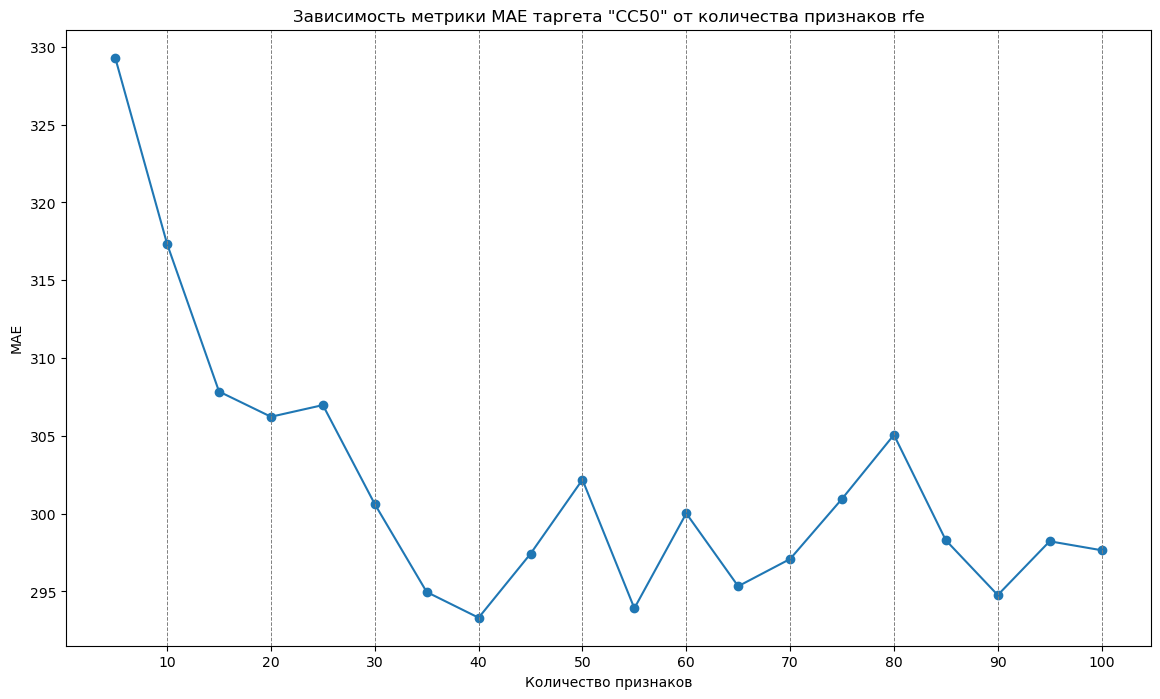

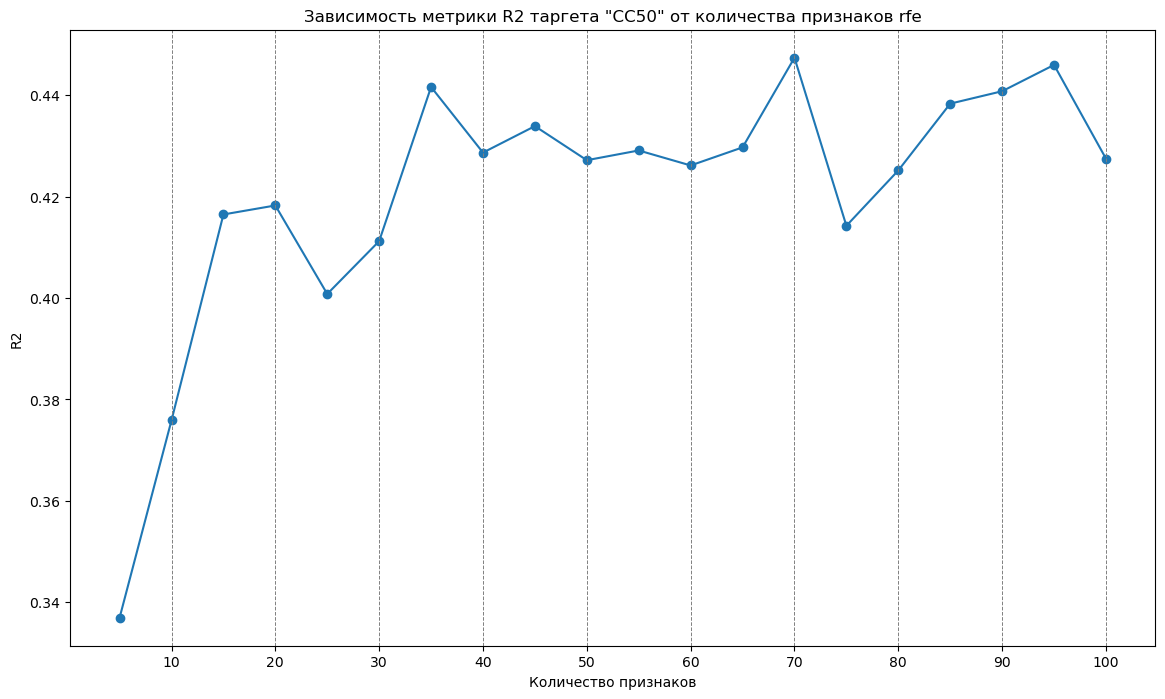

In [21]:
featureSelector.draw_selection(featureSelector.rfe_mae_scores, 'MAE', 'CC50', 'rfe')
featureSelector.draw_selection(featureSelector.rfe_r2_scores, 'R2', 'CC50', 'rfe')

In [22]:
featureSelector.print_kbest_result()

mae: 288.6939361466248
r2: 0.44632430150260516
Index(['MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed',
       'SPS', 'MaxPartialCharge', 'HallKierAlpha', 'TPSA', 'NHOHCount',
       'NumAliphaticHeterocycles', 'NumAromaticCarbocycles',
       'NumAromaticHeterocycles', 'NumAromaticRings', 'NumRotatableBonds',
       'MolLogP', 'fr_Al_COO', 'fr_Al_OH', 'fr_ArN', 'fr_Ar_COO', 'fr_Ar_NH',
       'fr_Ar_OH', 'fr_C_O', 'fr_C_S', 'fr_HOCCN', 'fr_Imine', 'fr_NH0',
       'fr_NH1', 'fr_NH2', 'fr_Ndealkylation1', 'fr_Ndealkylation2',
       'fr_alkyl_carbamate', 'fr_alkyl_halide', 'fr_allylic_oxid',
       'fr_amidine', 'fr_aniline', 'fr_aryl_methyl', 'fr_benzene',
       'fr_bicyclic', 'fr_epoxide', 'fr_ester', 'fr_ether', 'fr_furan',
       'fr_guanido', 'fr_halogen', 'fr_hdrzine', 'fr_hdrzone', 'fr_imide',
       'fr_ketone', 'fr_ketone_Topliss', 'fr_lactone', 'fr_methoxy',
       'fr_nitrile', 'fr_nitro', 'fr_oxime', 'fr_para_hydroxylation',
       'fr_piperzine', 'fr_pria

In [23]:
featureSelector.print_rfe_result()

mae: 297.0856798365284
r2: 0.447420905310851
Index(['MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed',
       'SPS', 'MaxPartialCharge', 'HallKierAlpha', 'TPSA', 'NHOHCount',
       'NumAliphaticHeterocycles', 'NumAromaticCarbocycles',
       'NumAromaticHeterocycles', 'NumAromaticRings', 'NumRotatableBonds',
       'MolLogP', 'fr_Al_OH', 'fr_Al_OH_noTert', 'fr_ArN', 'fr_Ar_COO',
       'fr_Ar_N', 'fr_Ar_NH', 'fr_Ar_OH', 'fr_C_S', 'fr_Imine', 'fr_NH0',
       'fr_NH2', 'fr_Ndealkylation1', 'fr_aldehyde', 'fr_alkyl_carbamate',
       'fr_allylic_oxid', 'fr_aniline', 'fr_benzene', 'fr_bicyclic',
       'fr_epoxide', 'fr_ester', 'fr_furan', 'fr_imidazole', 'fr_imide',
       'fr_ketone_Topliss', 'fr_lactone', 'fr_nitro_arom', 'fr_oxazole',
       'fr_oxime', 'fr_para_hydroxylation', 'fr_piperzine', 'fr_pyridine',
       'fr_quatN', 'fr_sulfide', 'fr_sulfonamd', 'fr_urea',
       'EState_VSA_median', 'EState_VSA_min', 'EState_VSA_variation',
       'VSA_EState_median', 'VSA

In [24]:
common_selected_features, combined_selected_features = featureSelector.get_selected_features()

# Эксперемент с моделями

In [26]:
run_models_regressions(X_train, X_test, y_train, y_test)

,Model,Mean Absolute Error,R2 Score
9,Krr,272.88,0.48
4,Gradient Boosting,264.24,0.47
2,Random Forest,277.54,0.45
3,XGBoost,271.62,0.45
6,CatBoost,297.65,0.43
5,LightGBM,293.47,0.41
7,HistGradientBoosting,301.20,0.40
8,AdaBoost,395.13,0.26
0,Decision Tree,282.97,0.25
1,KNeighbors,305.79,0.15


In [27]:
run_models_regressions(X_train[xgboost_features], X_test[xgboost_features], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
9,Krr,272.88,0.48
4,Gradient Boosting,262.85,0.47
2,Random Forest,277.12,0.45
6,CatBoost,295.13,0.45
3,XGBoost,275.73,0.44
5,LightGBM,293.47,0.41
7,HistGradientBoosting,301.20,0.40
8,AdaBoost,379.90,0.30
0,Decision Tree,289.78,0.25
1,KNeighbors,305.79,0.15


In [28]:
run_models_regressions(X_train[featureSelectorCV.best_features_names], X_test[featureSelectorCV.best_features_names], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
10,Krr,272.88,0.48
5,Gradient Boosting,263.11,0.47
3,Random Forest,278.11,0.45
4,XGBoost,270.80,0.45
7,CatBoost,293.10,0.44
6,LightGBM,293.47,0.41
8,HistGradientBoosting,301.20,0.40
0,Linear Regression,337.79,0.32
9,AdaBoost,385.53,0.28
1,Decision Tree,298.72,0.20


In [29]:
run_models_regressions(X_train[featureSelector.kbest_best_feature_names], X_test[featureSelector.kbest_best_feature_names], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
5,Gradient Boosting,271.21,0.46
10,Krr,280.73,0.46
3,Random Forest,279.62,0.45
4,XGBoost,265.57,0.45
7,CatBoost,288.69,0.45
6,LightGBM,290.22,0.43
8,HistGradientBoosting,308.81,0.38
0,Linear Regression,329.17,0.35
9,AdaBoost,385.64,0.27
1,Decision Tree,299.12,0.21


In [30]:
run_models_regressions(X_train[featureSelector.rfe_best_feature_names], X_test[featureSelector.rfe_best_feature_names], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
3,Random Forest,278.39,0.45
4,XGBoost,269.05,0.45
5,Gradient Boosting,270.09,0.45
7,CatBoost,297.09,0.45
10,Krr,291.01,0.42
6,LightGBM,292.67,0.41
8,HistGradientBoosting,308.54,0.37
0,Linear Regression,330.83,0.33
9,AdaBoost,390.36,0.27
1,Decision Tree,291.73,0.23


In [31]:
run_models_regressions(X_train[common_selected_features], X_test[common_selected_features], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
5,Gradient Boosting,263.25,0.47
3,Random Forest,277.90,0.45
4,XGBoost,273.42,0.45
7,CatBoost,301.83,0.42
6,LightGBM,290.91,0.41
10,Krr,294.76,0.41
8,HistGradientBoosting,306.19,0.38
0,Linear Regression,326.68,0.35
9,AdaBoost,397.19,0.26
1,Decision Tree,284.38,0.25


In [32]:
run_models_regressions(X_train[combined_selected_features], X_test[combined_selected_features], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
5,Gradient Boosting,267.53,0.47
10,Krr,279.40,0.46
3,Random Forest,276.16,0.45
4,XGBoost,272.09,0.45
7,CatBoost,290.89,0.45
6,LightGBM,291.90,0.41
8,HistGradientBoosting,301.20,0.40
0,Linear Regression,333.50,0.33
9,AdaBoost,391.77,0.28
1,Decision Tree,287.19,0.25


# Подбор гиперпараметров

In [67]:
gbr = GradientBoostingRegressor(random_state=42)
param_dist = {
    'n_estimators': randint(100, 500),  # Количество деревьев
    'max_depth': randint(3, 15),  # Максимальная глубина дерева
    'learning_rate': uniform(0.01, 0.3),  # Скорость обучения
    'subsample': uniform(0.6, 0.4),  # Доля выборок для обучения каждого дерева
    'min_samples_split': randint(2, 10),  # Минимальное количество образцов для разделения узла
    'min_samples_leaf': randint(1, 10),  # Минимальное количество образцов в листе
    'max_features': ['sqrt', 'log2', None],  # Количество признаков для разбиения
    'max_leaf_nodes': [None, 10, 20, 30],  # Максимальное количество листовых узлов
    'min_impurity_decrease': uniform(0.0, 0.1),  # Минимальное улучшение для разбиения узла
}

random_search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_dist,
    n_iter=300,
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

best_params = random_search.best_params_
print("Лучшие параметры:", best_params)

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

/Users/v.papadyk/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Лучшие параметры: {'learning_rate': 0.04403938060523441, 'max_depth': 7, 'max_features': 'log2', 'max_leaf_nodes': 10, 'min_impurity_decrease': 0.005755876001664429, 'min_samples_leaf': 5, 'min_samples_split': 4, 'n_estimators': 314, 'subsample': 0.8183663080659955}
Mean Absolute Error: 281.48065983055113
R2 Score: 0.4426598464861121


In [73]:
best_model = GradientBoostingRegressor(
    learning_rate=0.04,
    max_depth=7,
    max_features='log2',
    max_leaf_nodes=10,
    min_impurity_decrease=0.006,
    min_samples_leaf=5,
    min_samples_split=4,
    n_estimators=314,
    subsample=0.82,
    random_state=725,
    verbose=0,
)
best_model.fit(X_train[featureSelector.rfe_best_feature_names], y_train)
y_pred = best_model.predict(X_test[featureSelector.rfe_best_feature_names])

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae:.3f}')
print(f'R2 Score: {r2:.3f}')

Mean Absolute Error: 283.611
R2 Score: 0.445
